## Week 7 Exercises

###<font color=green> Replace the name below with **your name**. For full credit, your total needs to add up to 100 points.

I highly recommend reading the accompanying pdf for programming notes and other important details.

# Kavin Kannan

In [2]:
import numpy as np
from numpy import sin, cos, exp, sqrt
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import quad

1. Finding the zeros of the Bessel functions. (10 points)
This problem builds on last week’s problem in which you plotted the
Bessel function of the first kind, J1(x), over the range 0 ≤ x ≤ 20.
Repeat this plot: it will show you that you have a number of zeroes
(i.e. values of x for which J1(x) = 0. Use your plot to figure out how
many there are in this range, and roughly where those zeroes lie. Then
find a way to sample the function at suitable intervals, and by checking
where it changes sign, find the zeroes of J1(x) in the range 0 ≤ x ≤ 20.

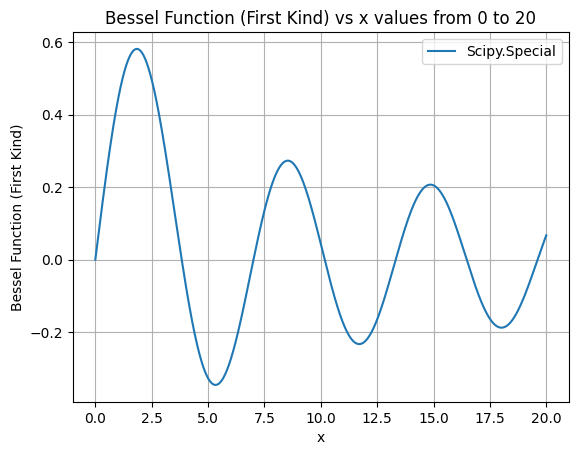

In [12]:
x_values_1 = np.linspace(0, 20, 20000)
Bessel_values_1_Special = np.zeros(len(x_values_1))
for i in range(len(x_values_1)):
    Bessel_values_1_Special[i] = scipy.special.jv(1, x_values_1[i])

plt.plot(x_values_1, Bessel_values_1_Special, label="Scipy.Special")
plt.xlabel("x")
plt.ylabel("Bessel Function (First Kind)")
plt.title("Bessel Function (First Kind) vs x values from 0 to 20")
plt.legend()
plt.grid()
plt.show()

In [20]:
Bessel_0values_1 = [0]
for i in range(2500, 5000):
    if Bessel_values_1_Special[i] < 0:
        Bessel_0values_1.append(float(x_values_1[i]))
        break
for i in range(5000, 7500):
    if Bessel_values_1_Special[i] > 0:
        Bessel_0values_1.append(float(x_values_1[i]))
        break
for i in range(10000, 12500):
    if Bessel_values_1_Special[i] < 0:
        Bessel_0values_1.append(float(x_values_1[i]))
        break
for i in range(12500, 15000):
    if Bessel_values_1_Special[i] > 0:
        Bessel_0values_1.append(float(x_values_1[i]))
        break
for i in range(15000, 17500):
    if Bessel_values_1_Special[i] < 0:
        Bessel_0values_1.append(float(x_values_1[i]))
        break
for i in range(17500, 20000):
    if Bessel_values_1_Special[i] > 0:
        Bessel_0values_1.append(float(x_values_1[i]))
        break

Bessel_0values_1

[0,
 3.8321916095804793,
 7.016350817540878,
 10.173508675433773,
 13.324666233311666,
 16.470823541177058,
 19.615980799039953]

2. Solving ODEs: Euler algorithm for the Simple Harmonic Oscillator

The Euler method for solving a differential equation is perhaps the
simplest method you can think of. Given
dy
dt = f(y, t)

this is written as a finite difference equation, where each new time is
calculated based on the previous value and a small time increment. This
is accurate to linear order in the expansion parameter, which represents
the time increment h = ∆t:
y(t + h) = y(t) + hf(y, t) or equivalently,
yn+1 = yn + hf(yn, tn).
If the time interval is divided into N steps, h = (b − a)/N, where a, b
are the starting and ending t values respectively.
Use the Euler method to solve the differential equation for a simple
harmonic oscillator. The equation of motion for a mass and spring
system is

m
d
2x
dt2
= −kx

This can be written as two linear ordinary differential equations (ODES):

dx
dt = v (1)
dv
dt = −
k
m
x (2)
Write each of these as a finite difference equation. Set k = 100 N/m
and m = 1 kg. Use an initial values of v = 0 m/s, and x = 0.1 m.
Using the Euler algorithm with a timestep h = 0.01s for both x and v,

(a) (5 points) Plot x and v as a function of time on two separate
graphs. Label your axes!

(b) (5 points) Plot total energy as a function of time.

(c) (5 points) Plot x vs v (phase space plot).

(d) (5 points) Finally, make your timestep h = 0.001 and 0.0001 and
increase the total number of steps N by a factor of 10 each time.
How do your results change for the energy plot (b)?

(e) (5 points) Describe what you observe for each plot. Do you see
why this algorithm is problematic? Explain in a markdown cell.

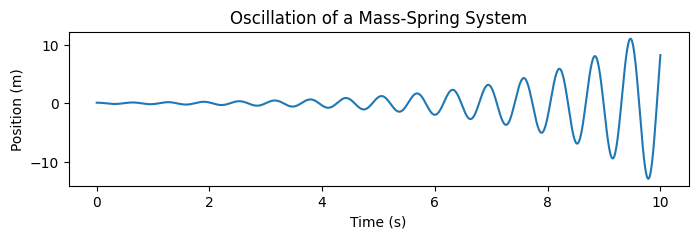

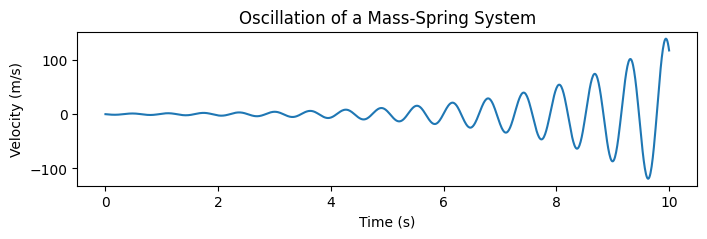

In [78]:
k = 100
m = 1
v0 = 0
x0 = 0.1

timestep_1_a = 0.01

def x_derivative_1(v):
    return v
def v_derivative_1(x,k,m):
    return -k * x / m

t_1_a = np.arange(0,10.01,timestep_1_a)  
x_1 = np.zeros(len(t_1_a))
v_1 = np.zeros(len(t_1_a))
x_1[0] = x0
v_1[0] = v0

h_1 = 10/len(t_1_a)

for j in range(len(t_1_a) - 1):
    x_1[j+1] = x_1[j] + h_1 * v_1[j]
    v_1[j+1] = v_1[j] + h_1 * (-k * x_1[j] / m)

plt.figure(figsize=(8,2))
plt.plot(t_1_a, x_1)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Oscillation of a Mass-Spring System")
plt.show()

plt.figure(figsize=(8,2))
plt.plot(t_1_a, v_1)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Oscillation of a Mass-Spring System")
plt.show()

In [79]:
KE_1 = 0.5 * m * (v_1)**2
U_1 = 0.5 * k * (x_1)**2
E_1_a = KE_1 + U_1

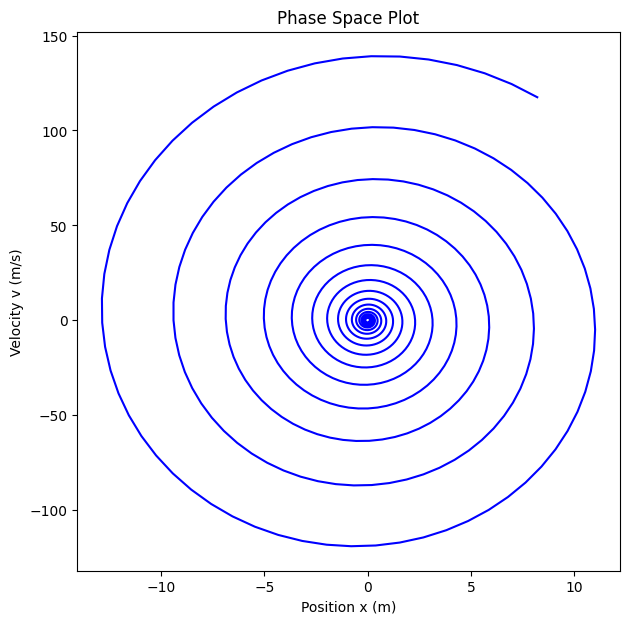

In [80]:
plt.figure(figsize=(7,7))
plt.plot(x_1, v_1, color='b')
plt.xlabel("Position x (m)")
plt.ylabel("Velocity v (m/s)")
plt.title("Phase Space Plot")
plt.show()

In [81]:
k = 100
m = 1
v0 = 0
x0 = 0.1

timestep_1_b = 0.001

def x_derivative_1(v):
    return v
def v_derivative_1(x,k,m):
    return -k * x / m

t_1_b = np.arange(0,10.01,timestep_1_b)  
x_1 = np.zeros(len(t_1_b))
v_1 = np.zeros(len(t_1_b))
x_1[0] = x0
v_1[0] = v0

h_1 = 10/len(t_1_b)

for j in range(len(t_1_b) - 1):
    x_1[j+1] = x_1[j] + h_1 * v_1[j]
    v_1[j+1] = v_1[j] + h_1 * (-k * x_1[j] / m)

KE_1 = 0.5 * m * (v_1)**2
U_1 = 0.5 * k * (x_1)**2
E_1_b = KE_1 + U_1


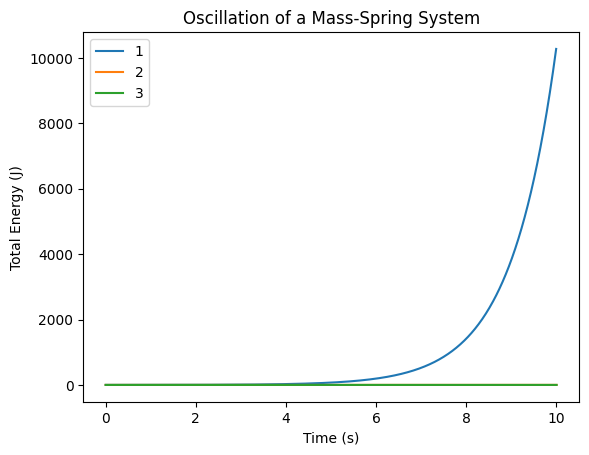

In [84]:
k = 100
m = 1
v0 = 0
x0 = 0.1

timestep_1_c = 0.0001

def x_derivative_1(v):
    return v
def v_derivative_1(x,k,m):
    return -k * x / m

t_1_c = np.arange(0,10.01,timestep_1_c)  
x_1 = np.zeros(len(t_1_c))
v_1 = np.zeros(len(t_1_c))
x_1[0] = x0
v_1[0] = v0

h_1 = 10/len(t_1_c)

for j in range(len(t_1_c) - 1):
    x_1[j+1] = x_1[j] + h_1 * v_1[j]
    v_1[j+1] = v_1[j] + h_1 * (-k * x_1[j] / m)

KE_1 = 0.5 * m * (v_1)**2
U_1 = 0.5 * k * (x_1)**2
E_1_c = KE_1 + U_1

plt.plot(t_1_a, E_1_a, label="1")
plt.plot(t_1_b, E_1_b, label='2')
plt.plot(t_1_c, E_1_c, label='3')
plt.xlabel("Time (s)")
plt.ylabel("Total Energy (J)")
plt.title("Oscillation of a Mass-Spring System")
plt.legend()
plt.show()

The reason this method of solving differntial equations is problematic is because of the slight innaccuracies. Obviously it gets better when timesteps are smaller, but Euler's method causes us to find an increase in total energy over time even in the 2nd and 3rd situations where it seems 0-like.

3. Solving ODEs: Euler-Cromer algorithm

(a) (5 points) Modify your code for the previous problem 2 to first
update the velocity v, then update x, such that the new x
value uses the updated v. This is the Euler-Cromer algorithm.
Repeat steps (a) - (c) of Problem 2.
2

(b) (5 points) How do your results change? Explain in a markdown
cell.

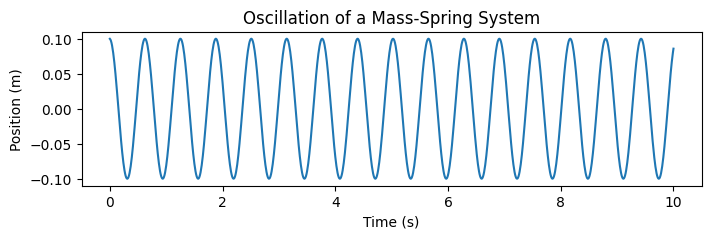

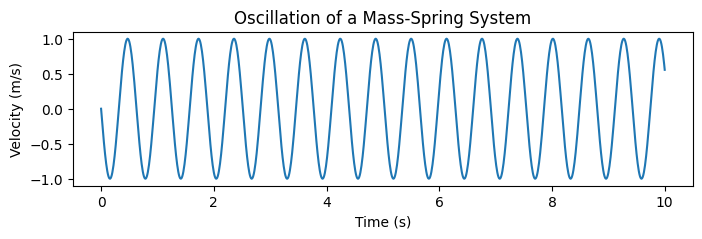

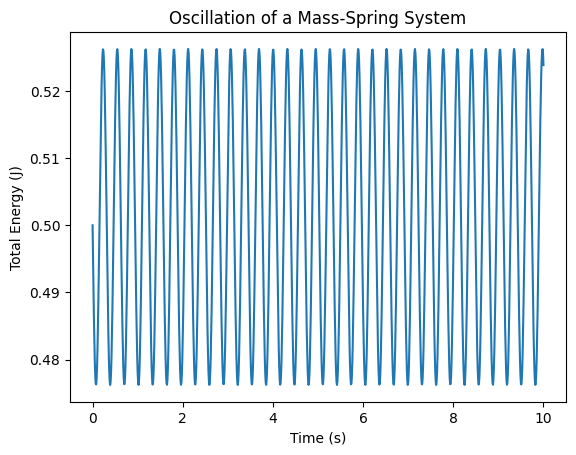

Text(0.5, 1.0, 'Phase Space Plot')

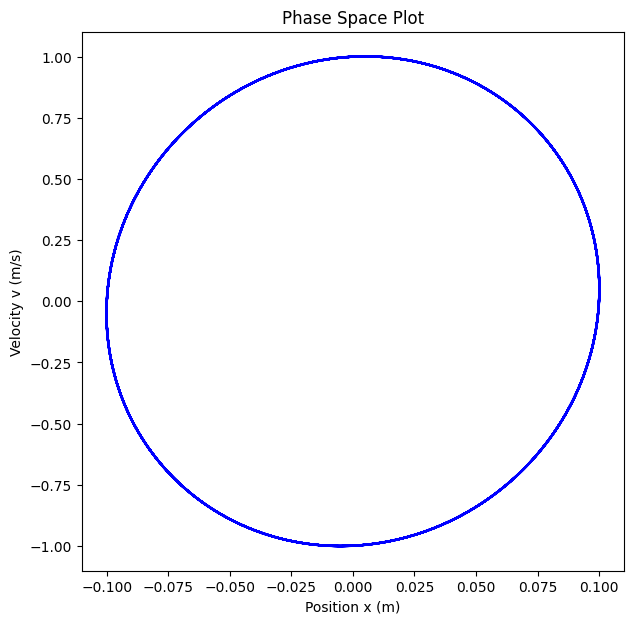

In [87]:
k = 100
m = 1
v0 = 0
x0 = 0.1

timestep_3 = 0.01

def x_derivative_1(v):
    return v
def v_derivative_1(x,k,m):
    return -k * x / m

t_3 = np.arange(0,10.01,timestep_3)  
x_3 = np.zeros(len(t_3))
v_3 = np.zeros(len(t_3))
x_3[0] = x0
v_3[0] = v0

h_3 = 10/len(t_3)

for j in range(len(t_3) - 1):
    v_3[j+1] = v_3[j] + h_3 * (-k * x_3[j] / m)
    x_3[j+1] = x_3[j] + h_3 * v_3[j+1]

plt.figure(figsize=(8,2))
plt.plot(t_3, x_3)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Oscillation of a Mass-Spring System")
plt.show()

plt.figure(figsize=(8,2))
plt.plot(t_3, v_3)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Oscillation of a Mass-Spring System")
plt.show()

KE_3 = 0.5 * m * (v_3)**2
U_3 = 0.5 * k * (x_3)**2
E_3 = KE_3 + U_3

plt.plot(t_3, E_3)
plt.xlabel("Time (s)")
plt.ylabel("Total Energy (J)")
plt.title("Oscillation of a Mass-Spring System")
plt.show()

plt.figure(figsize=(7,7))
plt.plot(x_3, v_3, color='b')
plt.xlabel("Position x (m)")
plt.ylabel("Velocity v (m/s)")
plt.title("Phase Space Plot")


The graphs become a lot more indicative of an oscillator. Even the energy begins to fluctuate around the value it's meant to be instead of strictly increasing. 

4. 2nd order Runge-Kutta algorithm
In the previous exercises, you compared the Euler and Euler-Cromer methods for integrating the second order differential equation of a sim-
ple harmonic oscillator. You would have observed that the Euler-Cromer does a little better in some respects. Here, you will use a second order Runge Kutta method to solve the same system.

(a) (10 points) Write your own 2nd order Runge Kutta code, then
compute and plot x and v as a function of time on two separate
graphs.

(b) (5 points) Plot total energy as a function of time.

(c) (5 points) Plot x vs v (phase space plot).

(d) (5 points) How do your results for the Runge Kutta algorithm
compare with those from Euler-Cromer? Explain in a markdown
cell.

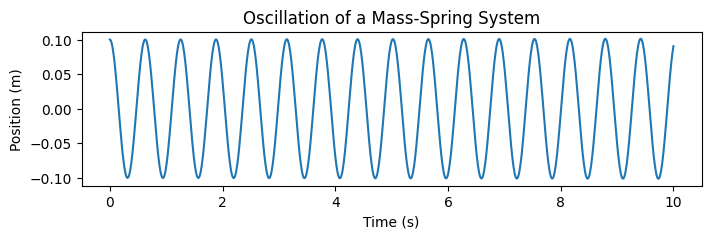

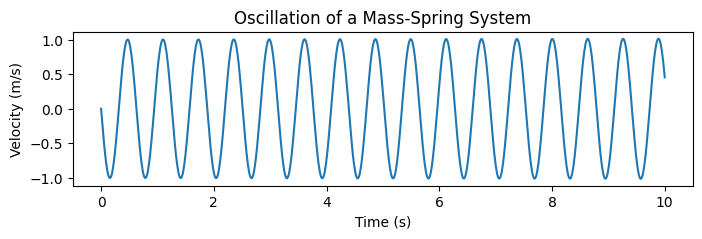

In [88]:
k = 100
m = 1
v0 = 0
x0 = 0.1

timestep_4 = 0.01

def x_derivative_4(v):
    return v
def v_derivative_4(x,k,m):
    return -k * x / m

t_4 = np.arange(0,10.01,timestep_4)  
x_4 = np.zeros(len(t_1_a))
v_4 = np.zeros(len(t_1_a))
x_4[0] = x0
v_4[0] = v0

h_4 = 10/len(t_4)

for j in range(len(t_4) - 1):
    x_mid = x_4[j] + (h_4 / 2) * v_4[j]
    v_mid = v_4[j] + (h_4 / 2) * (-k * x_4[j] / m)
    
    x_4[j+1] = x_4[j] + h_4 * v_mid
    v_4[j+1] = v_4[j] + h_4 * (-k * x_mid / m)



plt.figure(figsize=(8,2))
plt.plot(t_4, x_4)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Oscillation of a Mass-Spring System")
plt.show()

plt.figure(figsize=(8,2))
plt.plot(t_4, v_4)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Oscillation of a Mass-Spring System")
plt.show()

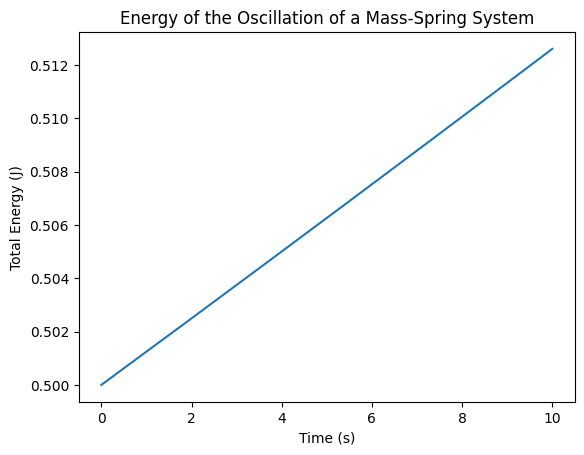

In [97]:
KE_4 = 0.5 * m * (v_4)**2
U_4 = 0.5 * k * (x_4)**2
E_4 = KE_4 + U_4

plt.plot(t_4, E_4)
plt.xlabel("Time (s)")
plt.ylabel("Total Energy (J)")
plt.title("Energy of the Oscillation of a Mass-Spring System")
plt.show()

Text(0.5, 1.0, 'Phase Space Plot')

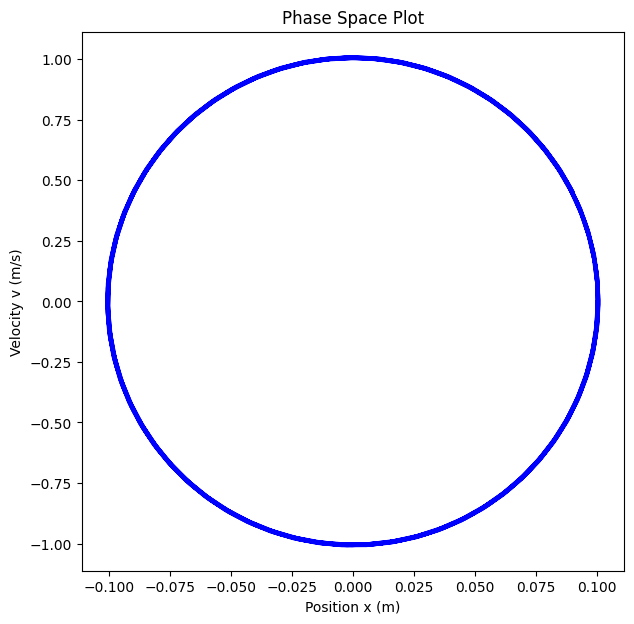

In [90]:
plt.figure(figsize=(7,7))
plt.plot(x_4, v_4, color='b')
plt.xlabel("Position x (m)")
plt.ylabel("Velocity v (m/s)")
plt.title("Phase Space Plot")

The oscillation graphs look very similar, and the phase plot looks similar (except for a slight tilt the Euler-Cromer). The biggest difference is in the energy graphs. There is an oscillation in the Euler-Cromer total energy around the actual total energy, whereas for the RK2 Energy, it starts at the actual total energy, then slowly increases.

5. Using Runge-Kutta: the simple pendulum
Use the second order Runge Kutta methods to solve the differential equation for a simple pendulum. With a small angle approximation, this is formally identical to the mass-spring system, and is a simple harmonic oscillator. The equation of motion for a pendulum of length
l is

d
2
θ
dt2
= −
g / l θ

This can be written as two linear ordinary differential equations (ODES):

dθ
dt = ω and dω
dt = −
g
l
θ

where the angle θ is expressed in radians, and ω is the angular
frequency in rad/s.
For your simulation, set g/l = 1, and use an initial values θ0 = π/6 rad
and ω0 = 0. Make your plots over a time range of 5 seconds with a
timestep of h = 0.01s.

(a) (5 points) Plot θ and ω as a function of time on two separate plots.

(b) (5 points) Make a phase space plot, i.e. plot ω vs θ.

(c) (5 points) In a markdown cell, write down a formula for the total
energy of the system as a function of ω(t) and θ(t). Plot the total
energy of the system as a function of time.
As always, when making plots, make sure your graphs have a title, axis
labels with units, and a legend.

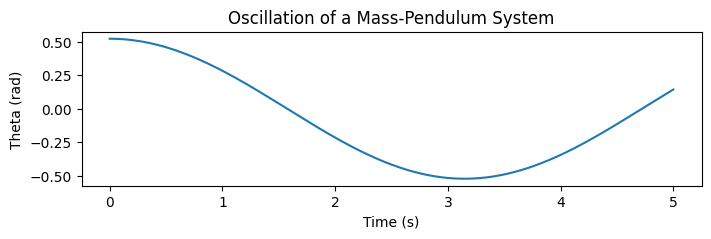

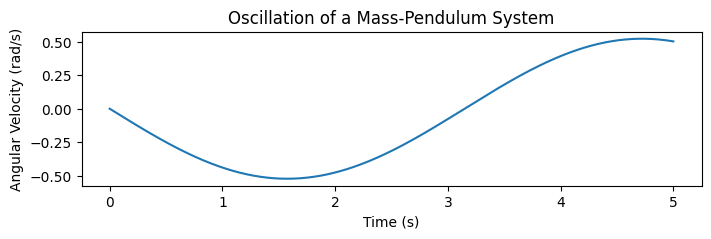

In [95]:
g = 9.81
l = 9.81
theta0 = np.pi / 6
w0 = 0

timestep_5 = 0.01

def theta_derivative_5(w):
    return w
def w_derivative_5(g, theta, l):
    return -g * theta / l

t_5 = np.arange(0,5.01,timestep_5)  
theta_5 = np.zeros(len(t_5))
w_5 = np.zeros(len(t_5))
theta_5[0] = theta0
w_5[0] = w0

h_5 = 5/len(t_5)

for j in range(len(t_5) - 1):
    theta_mid = theta_5[j] + (h_5 / 2) * w_5[j]
    w_mid = w_5[j] + (h_5 / 2) * (-g * theta_5[j] / l)
    
    theta_5[j+1] = theta_5[j] + h_5 * w_mid
    w_5[j+1] = w_5[j] + h_5 * (-g * theta_mid / l)



plt.figure(figsize=(8,2))
plt.plot(t_5, theta_5)
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.title("Oscillation of a Mass-Pendulum System")
plt.show()

plt.figure(figsize=(8,2))
plt.plot(t_5, w_5)
plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity (rad/s)")
plt.title("Oscillation of a Mass-Pendulum System")
plt.show()

Text(0.5, 1.0, 'Phase Space Plot')

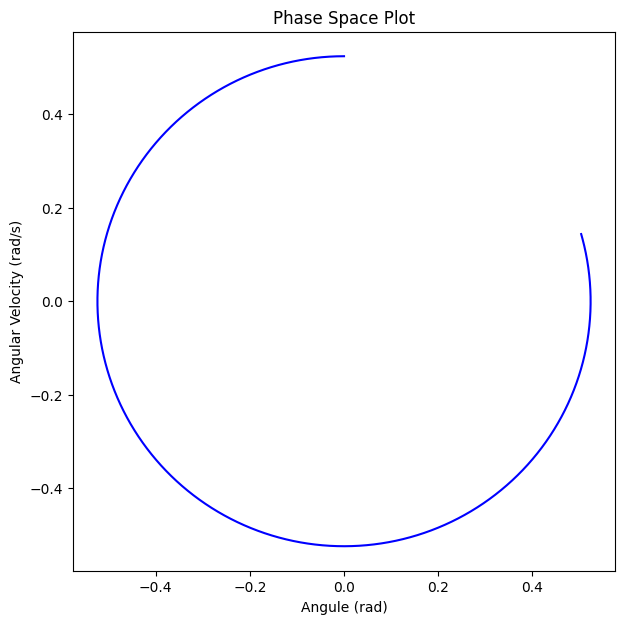

In [96]:
plt.figure(figsize=(7,7))
plt.plot(w_5, theta_5, color='b')
plt.xlabel("Angule (rad)")
plt.ylabel("Angular Velocity (rad/s)")
plt.title("Phase Space Plot")

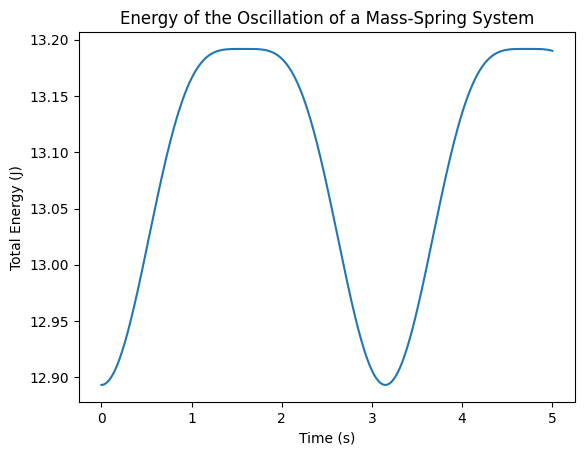

In [99]:
E_5 = 0.5 * m * l**2 * (w_5)**2 + m * g * l * (1 - np.cos(theta_5))

plt.plot(t_5, E_5)
plt.xlabel("Time (s)")
plt.ylabel("Total Energy (J)")
plt.title("Energy of the Oscillation of a Mass-Spring System")
plt.show()

6. Nonlinear Pendulum
The equation of motion for a nonlinear pendulum (with no small angle
approximation) of length l is
d
2
θ
dt2
= −
g
l
sin θ

This can be written as two ordinary differential equations (ODES):

dθ
dt = ω and dω
dt = −
g
l
sin θ

Set g = 9.8m/s2
, l = 1.

(a) (5 points) Compute and plot θ(t) over the range 0 < t < 5 s with
initial conditions at time t = 0 of θ = 0, ω = 1.0 rad/s. Explain
your results in terms of the expected period of the pendulum in the
linear regime |θ|  1, which corresponds to the simple harmonic
motion you explored in the previous problem.

(b) (10 points) Change your program to plot θ(t) for 50 different initial
conditions, all on the same graph (so there will be 50 curves on
this plot). For the 50 initial conditions at t = 0, make ω vary in
equal steps from zero to 10 rad/s, while keeping everything else
the same as in the previous part. If your variable for the initial
value of ω is called omega0 you can do this by writing
for omega0 in np.linspace(0,10,50):
You would put solving the ODE and adding a curve to the figure
inside the for loop.
The θ(t) curves should look different for large initial ω than for
small initial ω. Why is this? What is the exact value of initial ω
that separates the two behaviours?

(c) (5 points) Make a phase space plot, i.e. plot ω versus θ for the
same 50 initial conditions in part 6b - you will have 50 trajectories
in the ω versus θ plane. Set the θ limits of your plot to (−π, π).
You should find that some of the trajectories form closed curves in
phase space, while other trajectories do not. How does this relate
to your results from part 6b?

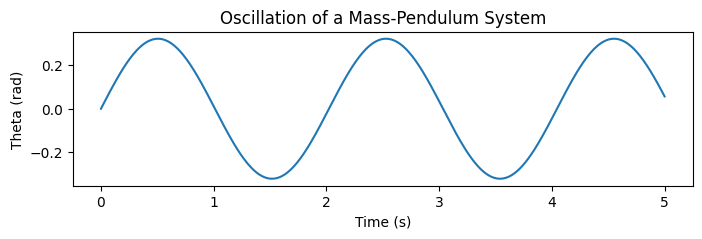

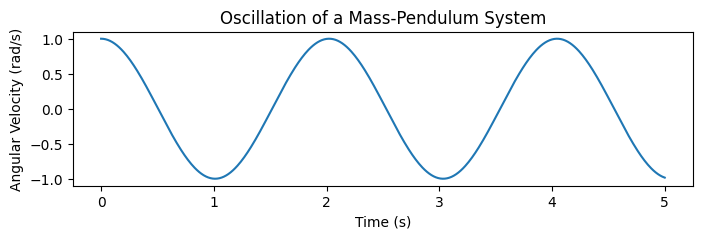

In [109]:
def Nonlinear_Pendulum(w):
    g = 9.81
    l = 1
    theta0 = 0
    w0 = w

    timestep_6 = 0.01

    def theta_derivative_6(w):
        return w
    def w_derivative_6(g, theta, l):
        return -g * np.sin(theta) / l

    t_6 = np.arange(0,5.01,timestep_6)  
    theta_6 = np.zeros(len(t_6))
    w_6 = np.zeros(len(t_6))
    theta_6[0] = theta0
    w_6[0] = w0

    h_6 = 5/len(t_6)

    for j in range(len(t_6) - 1):
        theta_mid = theta_6[j] + (h_6 / 2) * w_6[j]
        w_mid = w_6[j] + (h_6 / 2) * (-g * np.sin(theta_6[j]) / l)
        
        theta_6[j+1] = theta_6[j] + h_6 * w_mid
        w_6[j+1] = w_6[j] + h_6 * (-g * np.sin(theta_mid) / l)
    return(t_6, theta_6, w_6)

t_6, theta_6, w_6 = Nonlinear_Pendulum(1)

plt.figure(figsize=(8,2))
plt.plot(t_6, theta_6)
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.title("Oscillation of a Mass-Pendulum System")
plt.show()

plt.figure(figsize=(8,2))
plt.plot(t_6, w_6)
plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity (rad/s)")
plt.title("Oscillation of a Mass-Pendulum System")
plt.show()

Because w is small, the greatest theta it reaches before gravity pulls it back is still within the small angle approximation, thus, indicating that this graph and the one above are relatively similar with the main difference being the max distance it will reach on either side of the pendulum. The period of this graph is a lot shorter than that of the first graph because we've altered the value of l between problems (from 9.81 to 1). Thus, the formula for the period of a pendulum is significantly smaller in the second graph. However, this formula only holds for small angles. 

[]

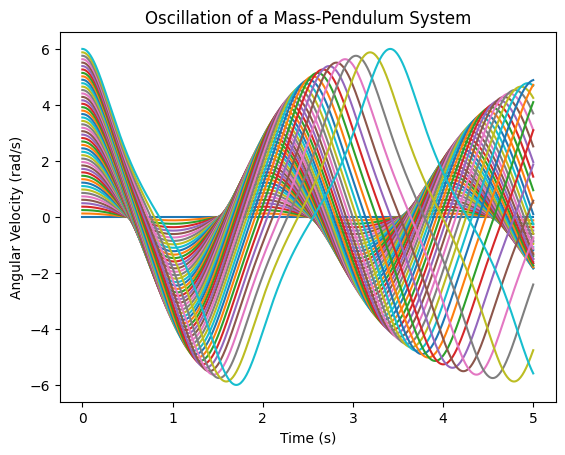

In [124]:
w_values = np.linspace(0,6,50)
for w in w_values:
    t_6, theta_6, w_6 = Nonlinear_Pendulum(w)

    plt.plot(t_6, w_6)
    plt.xlabel("Time (s)")
    plt.ylabel("Angular Velocity (rad/s)")
    plt.title("Oscillation of a Mass-Pendulum System")
plt.plot()

It seems like between w=3 and w=4, the small angle approximation for period starts to break down, then once w=6, all hell breaks loose.